<a href="https://colab.research.google.com/github/rohanjsheth/Paper-Recreation-Learning-from-Randomly-Initialized-Neural-Network-Features/blob/main/CIFARTest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install trimap

  Using cached trimap-1.2.0-py3-none-any.whl.metadata (15 kB)
  Using cached annoy-1.17.3.tar.gz (647 kB)
  Preparing metadata (setup.py) ... done
Using cached trimap-1.2.0-py3-none-any.whl (32 kB)
  Created wheel for annoy: filename=annoy-1.17.3-cp313-cp313-linux_x86_64.whl size=549206 sha256=3c679490c0daa9ac0bd4634cc6b944e86e7ed24d0c26932f7a8a9438724ea737
  Stored in directory: /root/.cache/pip/wheels/fc/4e/87/f1f957e7382aa370452cff98276f51686924d5415e449800ed
Successfully built annoy


In [ ]:
import os
import torch
import numpy as np
import torch.nn.functional as F
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, datasets
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [ ]:
class ResBlock(nn.Module):
  def __init__(self, in_channels, out_channels, conv_stride):
    super().__init__()
    self.first = torch.nn.Conv2d(in_channels, out_channels, 3,
                                 stride=conv_stride, padding=1)
    self.batch_norm1 = torch.nn.BatchNorm2d(out_channels)
    self.relu1 = torch.nn.ReLU()
    self.second = torch.nn.Conv2d(out_channels, out_channels, 3,
                                  stride=1, padding=1)
    self.batch_norm2 = torch.nn.BatchNorm2d(out_channels)
    self.relu2 = torch.nn.ReLU()

    if in_channels != out_channels or conv_stride != 1:
      self.shortcut = nn.Sequential(
          nn.Conv2d(
              in_channels, out_channels,
              kernel_size=1, stride=conv_stride, bias=False
          ),
          nn.BatchNorm2d(out_channels),
      )
    else:
      self.shortcut = nn.Identity()

  def forward(self, x):
    x_out = self.first(x)
    x_out = self.batch_norm1(x_out)
    x_out = self.relu1(x_out)
    x_out = self.second(x_out)
    x_out = self.batch_norm2(x_out)
    x_out = x_out + self.shortcut(x)
    x_out = self.relu2(x_out)
    return x_out

In [ ]:
class ResNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.first = nn.Sequential(
            nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        self.stages = nn.Sequential(
            nn.Sequential(ResBlock(64, 64, 1), ResBlock(64, 64, 1)),
            nn.Sequential(ResBlock(64, 128, 2), ResBlock(128, 128, 1)),
            nn.Sequential(ResBlock(128, 256, 2), ResBlock(256, 256, 1)),
            nn.Sequential(ResBlock(256, 512, 2), ResBlock(512, 512, 1)),
        )

        self.avg_pool = nn.AdaptiveAvgPool2d(1)

        #Kaming Normalization as per the paper: https://arxiv.org/pdf/2202.06438
        for layer in self.modules():
          if isinstance(layer, (nn.Conv2d, nn.Linear)):
              nn.init.kaiming_normal_(
                  layer.weight,
                  mode="fan_in",
                  nonlinearity="relu",
              )
              if layer.bias is not None:
                  nn.init.zeros_(layer.bias)

    def forward(self, x):
        x = self.first(x)
        x = self.stages(x)
        x = self.avg_pool(x)
        return x.flatten(1)

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),  # PIL → float tensor [3, 32, 32], scaled to [0, 1]
    transforms.Normalize(
        mean=(0.4914, 0.4822, 0.4465),
        std=(0.2470, 0.2435, 0.2616),
    ),
])

datasets.CIFAR10.url = (
    "https://cseweb.ucsd.edu/~weijian/static/datasets/cifar/"
    "cifar-10-python.tar.gz"
)

cifar_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

loader = DataLoader(cifar_dataset, batch_size=256, shuffle=False)

In [ ]:
loader = DataLoader(cifar_dataset, batch_size=64, shuffle=False, num_workers=2)

In [ ]:
#Larger iters --> convergence
#Note that for iters > 100, more efficent to update similarity matrix directly
meta_features = []
all_labels = []
num_iters = 50

for i in range(num_iters):
    print(f"Iteration {i+1}/{num_iters}")
    net = ResNet().to(device)
    net.eval()
    features = []

    with torch.no_grad():
        for images, labels in loader:
            features.append(net(images.to(device)).cpu())

            if i == 0:
                all_labels.append(labels.cpu())

    meta_features.append(torch.cat(features, dim=0))

X = torch.cat(meta_features, dim=1)
y = torch.cat(all_labels, dim=0).long()

del meta_features, features
import gc
gc.collect()

Iteration 1/50
Iteration 2/50
Iteration 3/50
Iteration 4/50
Iteration 5/50
Iteration 6/50
Iteration 7/50
Iteration 8/50
Iteration 9/50
Iteration 10/50
Iteration 11/50
Iteration 12/50
Iteration 13/50
Iteration 14/50
Iteration 15/50
Iteration 16/50
Iteration 17/50
Iteration 18/50
Iteration 19/50
Iteration 20/50
Iteration 21/50
Iteration 22/50
Iteration 23/50
Iteration 24/50
Iteration 25/50
Iteration 26/50
Iteration 27/50
Iteration 28/50
Iteration 29/50
Iteration 30/50
Iteration 31/50
Iteration 32/50
Iteration 33/50
Iteration 34/50
Iteration 35/50
Iteration 36/50
Iteration 37/50
Iteration 38/50
Iteration 39/50
Iteration 40/50
Iteration 41/50
Iteration 42/50
Iteration 43/50
Iteration 44/50
Iteration 45/50
Iteration 46/50
Iteration 47/50
Iteration 48/50
Iteration 49/50
Iteration 50/50


16

In [ ]:
loss_fn = nn.CrossEntropyLoss()

class trainableNet(nn.Module):
  def __init__(self, in_features):
    super().__init__()
    self.fc = nn.Linear(in_features, 10)

In [ ]:
training_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(X, y),
    batch_size=256,
    shuffle=True,
)

model = nn.Linear(X.shape[1], 10).to(device)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

In [ ]:
def train_one_epoch(epoch_index, tb_writer=None):
    model.train()
    total_loss = 0.0
    total_examples = 0

    for i, (inputs, labels) in enumerate(training_loader):
        inputs = inputs.to(device)
        labels = labels.to(device, dtype=torch.long)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * inputs.size(0)
        total_examples += inputs.size(0)

        if tb_writer is not None:
            step = epoch_index * len(training_loader) + i
            tb_writer.add_scalar("Loss/train", loss.item(), step)

    avg_loss = total_loss / total_examples
    print(f"Epoch {epoch_index}: loss {avg_loss:.4f}")
    return avg_loss

In [ ]:
num_epochs = 250
for epoch in range(num_epochs):
  train_one_epoch(epoch, tb_writer=None)

Epoch 0: loss 2.5177
Epoch 1: loss 2.0786
Epoch 2: loss 1.9751
Epoch 3: loss 1.9132
Epoch 4: loss 1.8642
Epoch 5: loss 1.8239
Epoch 6: loss 1.8011
Epoch 7: loss 1.7681
Epoch 8: loss 1.7467
Epoch 9: loss 1.7182
Epoch 10: loss 1.7036
Epoch 11: loss 1.6868
Epoch 12: loss 1.6640
Epoch 13: loss 1.6511
Epoch 14: loss 1.6369
Epoch 15: loss 1.6247
Epoch 16: loss 1.6098
Epoch 17: loss 1.5990
Epoch 18: loss 1.5958
Epoch 19: loss 1.5800
Epoch 20: loss 1.5697
Epoch 21: loss 1.5566
Epoch 22: loss 1.5498
Epoch 23: loss 1.5353
Epoch 24: loss 1.5366
Epoch 25: loss 1.5251
Epoch 26: loss 1.5166
Epoch 27: loss 1.5024
Epoch 28: loss 1.5036
Epoch 29: loss 1.4953
Epoch 30: loss 1.4840
Epoch 31: loss 1.4781
Epoch 32: loss 1.4771
Epoch 33: loss 1.4746
Epoch 34: loss 1.4658
Epoch 35: loss 1.4565
Epoch 36: loss 1.4513
Epoch 37: loss 1.4363
Epoch 38: loss 1.4338
Epoch 39: loss 1.4276
Epoch 40: loss 1.4210
Epoch 41: loss 1.4274
Epoch 42: loss 1.4077
Epoch 43: loss 1.4014
Epoch 44: loss 1.4033
Epoch 45: loss 1.404

KeyboardInterrupt: 

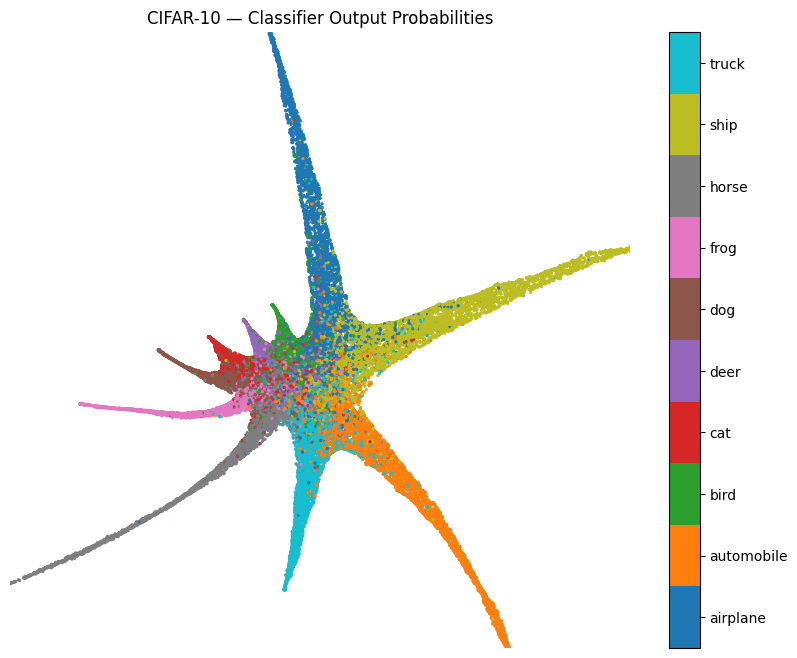

In [ ]:
import matplotlib.pyplot as plt
import trimap

model.eval()
all_probs = []

with torch.no_grad():
    for batch in X.split(256):
        logits = model(batch.to(device))
        all_probs.append(torch.softmax(logits, dim=1).cpu())

probs = torch.cat(all_probs, dim=0)

embedding = trimap.TRIMAP(n_dims=2).fit_transform(probs.numpy())

plt.figure(figsize=(10, 8))
points = plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=y.cpu().numpy(),
    cmap="tab10",
    vmin=-0.5, vmax=9.5,
    s=2,
)

cbar = plt.colorbar(points, ticks=range(10))
cbar.ax.set_yticklabels(cifar_dataset.classes)

plt.title("CIFAR-10 — Classifier Output Probabilities")
plt.axis("off")

lo, hi = np.quantile(embedding, [0.005, 0.995], axis=0)
pad = 0.05 * (hi - lo)

plt.xlim(lo[0] - pad[0], hi[0] + pad[0])
plt.ylim(lo[1] - pad[1], hi[1] + pad[1])



plt.show()

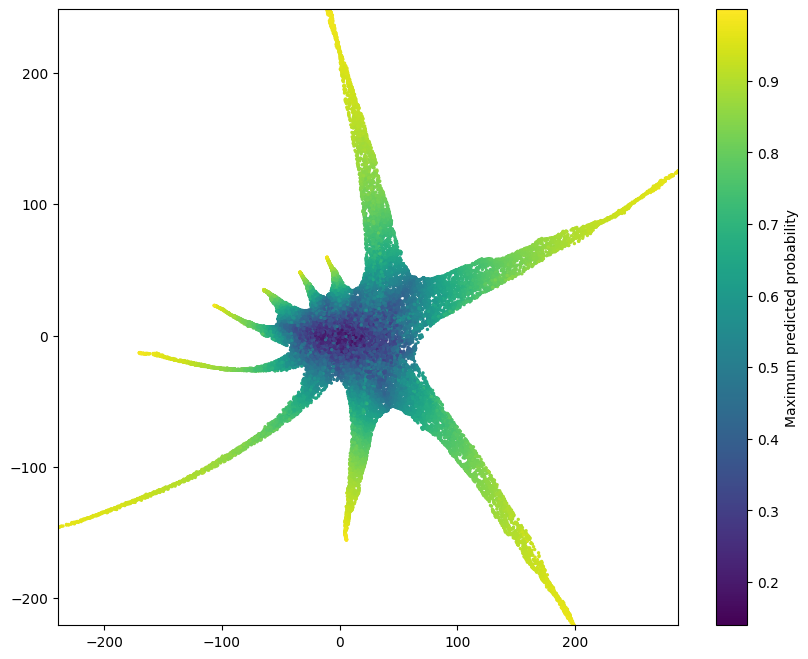

In [ ]:
confidence = probs.max(dim=1).values.cpu().numpy()

plt.figure(figsize=(10, 8))
plt.scatter(
    embedding[:, 0], embedding[:, 1],
    c=confidence, cmap="viridis", s=2,
)
plt.colorbar(label="Maximum predicted probability")
plt.xlim(lo[0] - pad[0], hi[0] + pad[0])
plt.ylim(lo[1] - pad[1], hi[1] + pad[1])
plt.show()

In [ ]:
accuracy = (
    probs.cpu().argmax(dim=1) == y.cpu()
).float().mean().item()

print(f"Accuracy: {accuracy:.1%}")

Accuracy: 68.4%
